# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Respuesta**
En la tabla **users** se observa que:
- la columna city cuenta con un 11,7% de valores nulos, se deben dejar como valores nulos(NaN).
- la Columna churn_date cuenta con 88.35% de valores nulos, sin embargo al tratarse de una fecha de retiro, quiere decir que si esta vacio son usuarios que siguen activos, por lo que podría tratarse como un tipo de dato booleano

En la tabla **usage** 

- la columna date tiene 0.125% de datos nulos, lo que representa un porcentaje muy bajo, por lo que se podrian conservar como NaT.
- la columna Duration tiene un 55.19% de datos nulos, pero hay que revisar si esto se debe a otra columna, por ejemplo type, donde la duracion no aplica
- la columna length cuenta con el 44.64% de los valores nulos sin embargo tambien hay que revisar si estos valores dependen de otro factor. 

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Es un identificador único por usuario (rango 10000–13999)
- La columna `age`  el mínimo es -999, lo cual es imposible para una edad real. Esto es un sentinel value que probablemente se usó para representar "dato faltante" en vez de NaN

In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` id es el identificador de cada registro de uso (1 a 40000, uno por fila). user_id es la llave foránea que conecta con la tabla users (mismo rango 10000–13999)
- Las columnas 'duration' y 'length' Ambas tienen un count menor a 40000 (17924 y 22104 respectivamente), confirmando los nulos 

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"--- {col} ---")
    print(users[col].unique())
    print()

--- city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

--- plan ---
['Basico' 'Premium']



- La columna `city`  Tiene un valor '?', es otro tipo de nulo disfrazado como texto. se debe reemplazar por NaN
- La columna `plan`  tiene dos categorías limpias. No requiere limpieza.

In [15]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` tiene dos valores: 'call' y 'text', sin nulos. No requiere limpieza

---
**Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores invalidos o sentinels**
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?

  En **users**

  - la columna 'age': tiene un valor sentinel (-999) el cual se reemplazará con la mediana.
  - la columna 'city': tiene un sentinel ('?') que se reemplazará con pd.NA.

  En **usage**

  - las columnas 'duration' y 'length' no tienen sentinels como tal, sin embargo cuentan con bastantes nulos. antes de imputar o eliminar, hay que revisar si el patrón de nulos depende de otra columna. 
  


### 2.3 Revisión y estandarización de fechas

**Objetivo:**
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.
- Revisa cuántas veces aparece cada año
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, 2022, 2023 y 2024 tienen volúmenes similares y consistentes, esto parece un crecimiento normal de usuarios año a año, el año 2026 es un error de captura, debe marcarse como NaT.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


 En `date`  el 100% de los registros con fecha válida caen en 2024


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  


- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  Sí. En reg_date de users aparece el año 2026, con 40 registros. sin embargo, esos mismos usuarios ya tienen registros de uso (usage.date) en 2024, es decir, dos años antes de su supuesta fecha de registro. Eso es lógicamente inconsistente: nadie puede usar el servicio antes de haberse registrado.

  
- ¿Qué harías con ellas?

Verificaría primero: cruzaría los user_id de esos 40 registros con usage para confirmar que efectivamente tienen uso antes de su reg_date. Como son solo 40 de ~4000 registros (1%), es un caso de corrección puntual, no justifica eliminar la columna completa, solo anular o corregir esas filas específicas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [22]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [24]:
# Verificación MAR en usage (Missing At Random) para length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

'duration' es nulo el 100% de las veces cuando type == 'text', y 'length' es nulo el 100% cuando type == 'call'. Esto confirma que son MAR: el nulo depende de la variable type, no es aleatorio. Se dejan como nulos porque tienen sentido estructural (una llamada no tiene 'longitud de mensaje'

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:

# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 



Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 



**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

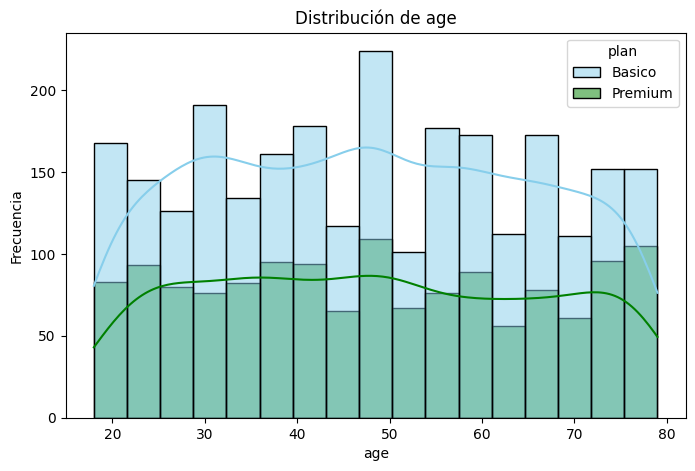

In [30]:
# Histograma para visualizar la edad (age)
for col in ['age']:
    plt.figure(figsize=(8,5))
    sns.histplot(data=user_profile, x=col, hue='plan', palette=['skyblue','green'], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- Distribución: La distribución general de ambos planes combinados es prácticamente simétrica, con una distribución bastante pareja de usuarios entre los 20 y 80 años, y una concentración un poco más marcada entre los 45 y 55 años.  a mayor edad, mayor proporción relativa de usuarios Premium. Esto sugiere que los usuarios más jóvenes prefieren o acceden más al plan Básico (quizás por precio o necesidades de uso más simples), mientras que los usuarios de mayor edad tienden a inclinarse más hacia Premium a medida que envejecen 

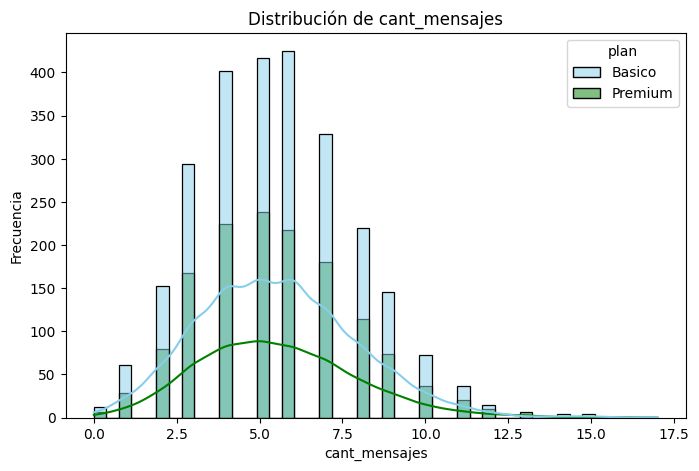

In [31]:
# Histograma para visualizar la cant_mensajes

for col in ['cant_mensajes']:
    plt.figure(figsize=(8,5))
    sns.histplot(data=user_profile, x=col, hue='plan', palette=['skyblue','green'], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

💡Insights: 
- La distribución está sesgada a la derecha (sesgo positivo) — la mayoría de los usuarios envía entre 2.5 y 7.5 mensajes, con un pico claro alrededor de 5-6 mensajes, y luego una cola larga que se extiende hacia valores altos (10-17.5 mensajes) con frecuencias cada vez menores.
- No existe un patrón claro que indique que un plan envía sistemáticamente más o menos mensajes que el otro en proporción

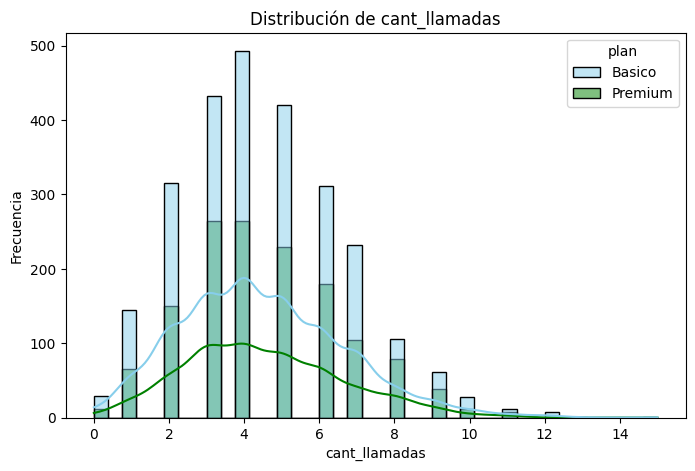

In [32]:
# Histograma para visualizar la cant_llamadas

for col in ['cant_llamadas']:
    plt.figure(figsize=(8,5))
    sns.histplot(data=user_profile, x=col, hue='plan', palette=['skyblue','green'], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


💡Insights: 
- La distribución está sesgada a la derecha (sesgo positivo) — el pico se concentra entre 3 y 5 llamadas, y luego decae de forma constante hacia la derecha, con muy pocos usuarios haciendo más de 10 llamadas.
- Los usuarios del plan Básico tienden a hacer más llamadas que los de Premium.  Esto podría sugerir que el plan Básico está más orientado o es más usado para llamadas de voz

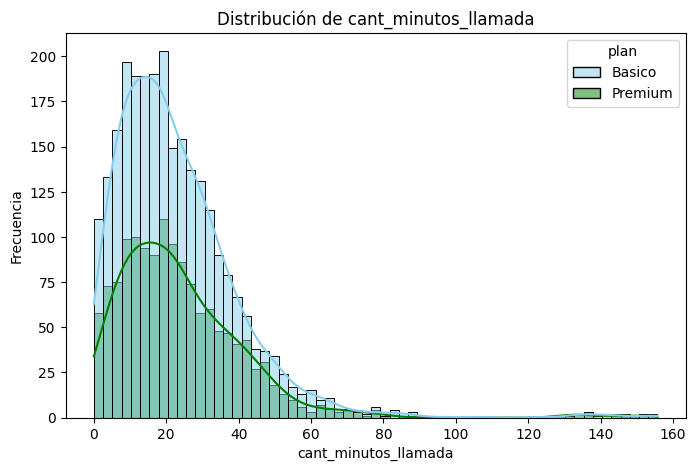

In [33]:
# Histograma para visualizar la cant_minutos_llamada
for col in ['cant_minutos_llamada']:
    plt.figure(figsize=(8,5))
    sns.histplot(data=user_profile, x=col, hue='plan', palette=['skyblue','green'], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()


💡Insights: 
- La distribución está sesgada a la derecha (sesgo positivo)  El pico se concentra entre 10 y 20 minutos, con una caída constante después, y una cola larga y notoria que se extiende hasta 160 minutos con frecuencias muy bajas.No solo los usuarios Básico hacen más llamadas, sino que también acumulan más minutos totales de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

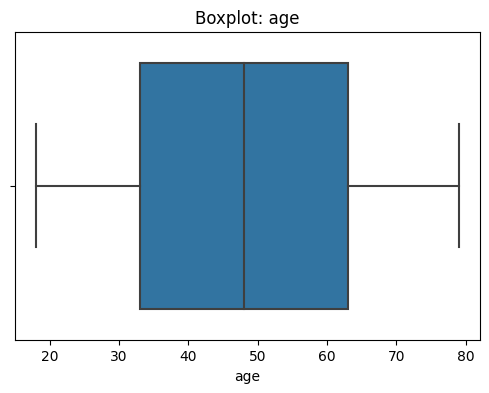

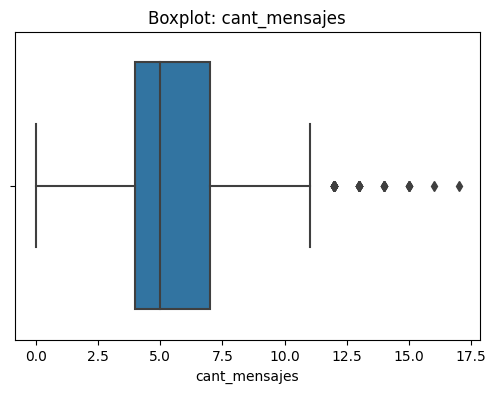

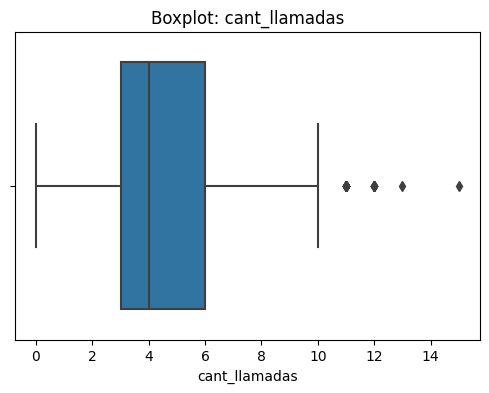

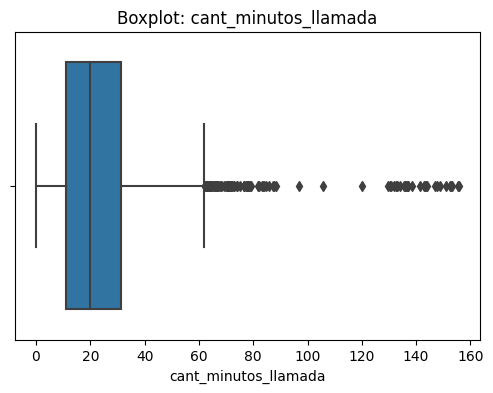

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No existen outliers, los bigotes cubren todo el rango de datos (18-79), sin ningún punto fuera de ellos. Distribución limpia.
- cant_mensajes: Sí existen outliers, solo del lado derecho, puntos aislados entre 12 y 17 mensajes, por encima del bigote superior (~11).
- cant_llamadas: Sí existen outliers, solo del lado derecho, puntos aislados entre 11 y 15 llamadas, por encima del bigote superior (~10).
- cant_minutos_llamada: sí existen outliers, del lado derecho, una cantidad considerable de puntos por encima de ~60 minutos, extendiéndose hasta 160. Es la variable con más outliers y la cola más larga.

In [35]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    limite_superior = q3 + 1.5 * iqr
    limite_inferior = q1 - 1.5 * iqr
    print(f"{col}: límite inferior = {limite_inferior:.2f}, límite superior = {limite_superior:.2f}")


cant_mensajes: límite inferior = -0.50, límite superior = 11.50
cant_llamadas: límite inferior = -1.50, límite superior = 10.50
cant_minutos_llamada: límite inferior = -19.32, límite superior = 61.86


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
mantener los outliers sin capar, son usuarios que envían más mensajes de lo normal, pero no de forma extrema — es un comportamiento plausible, no un error. No justifica modificar el dato.

- cant_llamadas: mantener o no outliers, porqué?

mantener los outliers. Representan usuarios con más llamadas de lo típico, dentro de un rango razonable de comportamiento real, no distorsionan significativamente la media.

- cant_minutos_llamada: mantener o no outliers, porqué?
- 
   aplicar Winsorizing sobre la columna, capando los valores por encima de 61.86. probablemente hay unos pocos usuarios con llamadas anormalmente largas (quizás errores de medición o casos muy atípicos de uso)

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)

In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

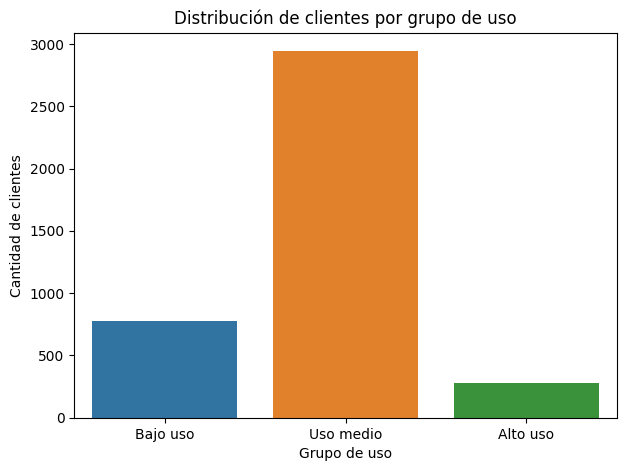

In [41]:
# Visualización de los segmentos por uso

plt.figure(figsize=(7,5))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso','Uso medio','Alto uso'])
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()



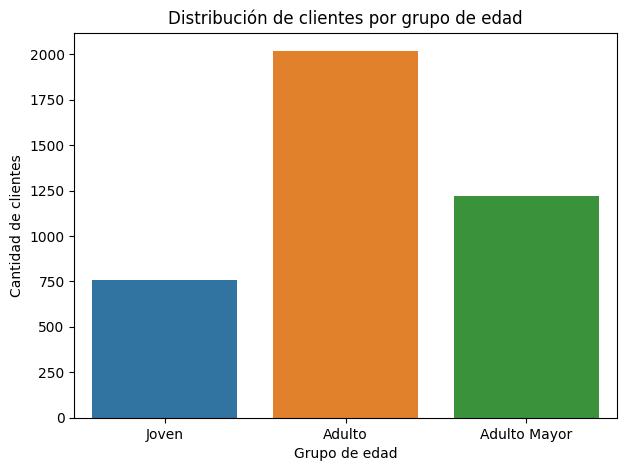

In [43]:
# Visualización de los segmentos por edad
plt.figure(figsize=(7,5))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

age: tenía un valor sentinel -999 (edad imposible). No se especifica en el notebook cuántas filas exactas tenían este valor, pero se detectó a través del mínimo en .describe().
city: tenía 469 nulos reales (11.7%) más un valor '?' como sentinel de texto. Al unificar ambos, el total quedó en 565 nulos (14.1% de 4000 filas).
reg_date: 40 filas (1%) con año 2026, inconsistente porque esos usuarios ya tenían uso registrado en 2024.
churn_date: 3534 nulos (88.35%), pero no es un error — representa usuarios activos.
date (usage): 50 nulos (0.125%).
duration (usage): 22,076 nulos (55.19%).
length (usage): 17,896 nulos (44.74%).

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Por edad (grupo_edad): Joven (age < 30), Adulto (30 ≤ age < 60), Adulto Mayor (age ≥ 60).
Por uso (grupo_uso): Bajo uso (llamadas < 5 y mensajes < 5), Uso medio (llamadas < 10 y mensajes < 10), Alto uso (el resto).
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Los usuarios de Alto uso combinados con Adulto Mayor + Premium parecen los más valiosos: son quienes más consumen y quienes más pagan por el plan de mayor precio, lo que los hace más rentables. Los usuarios Básico de Alto uso en llamadas también son valiosos como oportunidad de upselling, porque ya consumen como un usuario Premium sin pagar ese precio.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

age: no existen outliers (rango 18-79 dentro de los bigotes).
cant_mensajes: outliers solo del lado derecho, entre 12 y 17 mensajes.
cant_llamadas: outliers solo del lado derecho, entre 11 y 15 llamadas.
cant_minutos_llamada: outliers del lado derecho, considerables, por encima de ~62 minutos y hasta 155.69 minutos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Crear un plan intermedio para usuarios con alto uso de llamadas que no necesitan todo lo que incluye Premium.
Revisar los minutos incluidos en el plan Básico, ya que es el segmento con mayor consumo de minutos y mayor riesgo de cargos extra.
Diseñar campañas de upselling hacia usuarios Básico de mayor edad, dado que ese segmento muestra mayor tendencia a migrar a Premium.
Dar seguimiento especial a los usuarios "outliers" en minutos de llamada como candidatos a ofertas personalizadas de mayor valor.

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- age tenía un valor sentinel -999 (edad imposible), que distorsionaba la media; city tenía 565 nulos (14.1%) entre nulos reales y el valor '?' usado como sentinel de texto.
- reg_date tenía 40 filas (1%) con año 2026, inconsistente porque esos usuarios ya tenían uso registrado en 2024; duration y length de usage tenían 55.19% y 44.74% de nulos, pero se confirmó que son MAR (dependen 100% de type), por lo que se dejaron como nulos.


🔍 **Segmentos por Edad**

Se crearon tres grupos (Joven <30, Adulto 30-59, Adulto Mayor 60+) sobre un rango de edades de 18 a 79 años con distribución bastante pareja.
A mayor edad, mayor proporción relativa de usuarios con plan Premium; los usuarios más jóvenes se concentran más en el plan Básico.

📊 **Segmentos por Nivel de Uso**

Se crearon tres grupos (Bajo uso, Uso medio, Alto uso) según cantidad de llamadas y mensajes, con medianas de referencia de 4 llamadas y 5 mensajes.
Los usuarios del plan Básico muestran mayor volumen de llamadas y minutos totales que Premium, mientras que en mensajes no hay diferencia clara entre planes.

➡️ Esto sugiere que ...

 el uso del plan Premium está más asociado a la edad del usuario que a un mayor volumen de consumo real — funciona más como plan de preferencia que como uno realmente aprovechado por alto uso. Los usuarios Básico, aunque pagan menos, son quienes más minutos consumen, lo que los expone a mayor riesgo de cargos extra por excedentes.

💡 **Recomendaciones**


Crear un plan intermedio para usuarios (especialmente jóvenes/adultos) con alto uso de llamadas que no necesitan todo lo que incluye Premium, y revisar los minutos incluidos en el plan Básico para reducir el riesgo de sobrecostos y posible churn.
Diseñar campañas de upselling hacia usuarios Básico de mayor edad (mayor probabilidad de migrar a Premium) y dar seguimiento especial a los "outliers" en minutos de llamada (>62 min, hasta 155.69) como candidatos a ofertas personalizadas de mayor valor.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/nataliasepulveda-28/analysis-connectatel`